In [3]:
!pip install numpy matplotlib seaborn pandas
!pip install scikit-learn


Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


r2_score : 0.46
RMSE : 1646537.320889681
              precision    recall  f1-score   support

     1750000       0.00      0.00      0.00       1.0
     1820000       0.00      0.00      0.00       1.0
     1855000       0.00      0.00      0.00       0.0
     1890000       0.00      0.00      0.00       2.0
     2100000       0.00      0.00      0.00       1.0
     2233000       0.00      0.00      0.00       1.0
     2275000       0.00      0.00      0.00       1.0
     2380000       0.00      0.00      0.00       1.0
     2408000       0.00      0.00      0.00       0.0
     2450000       0.00      0.00      0.00       2.0
     2520000       0.00      0.00      0.00       1.0
     2653000       0.00      0.00      0.00       0.0
     2660000       0.00      0.00      0.00       4.0
     2730000       0.00      0.00      0.00       0.0
     2800000       0.00      0.00      0.00       1.0
     2870000       0.00      0.00      0.00       1.0
     2940000       0.00      0.00      0

C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1497:

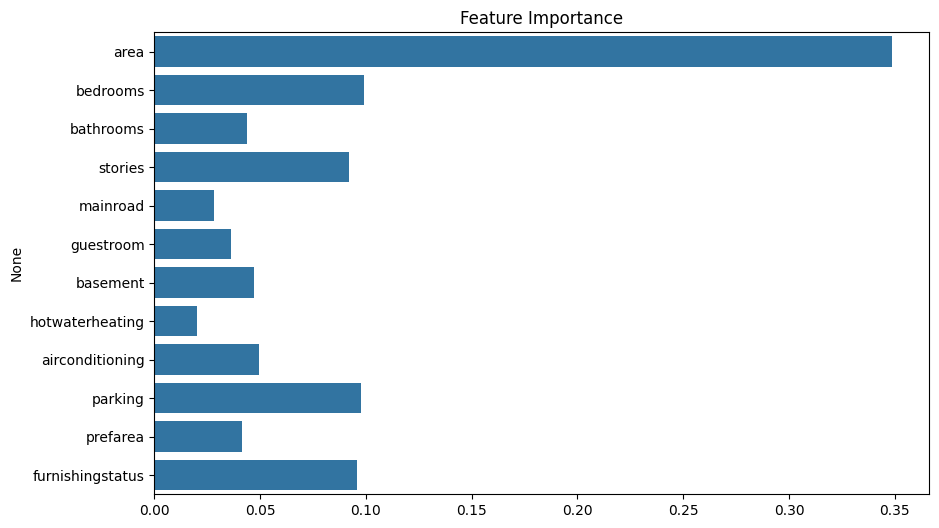

<Axes: xlabel='price', ylabel='area'>

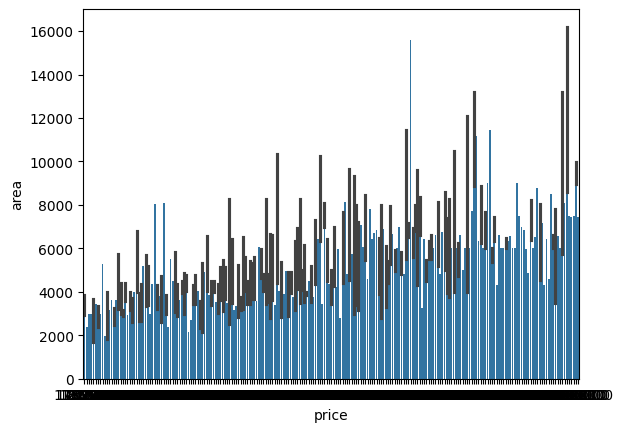

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,mean_squared_error, confusion_matrix,r2_score

df = pd.read_csv('Dataset/Housing.csv')
df.sample(10)

le = LabelEncoder()
df['mainroad'] = le.fit_transform(df['mainroad'])
df['guestroom'] = le.fit_transform(df['guestroom'])
df['basement'] = le.fit_transform(df['basement'])
df['hotwaterheating'] = le.fit_transform(df['hotwaterheating'])
df['airconditioning'] = le.fit_transform(df['airconditioning'])
df['prefarea'] = le.fit_transform(df['prefarea'])
df['furnishingstatus'] = le.fit_transform(df['furnishingstatus'])
x = df.drop(columns=['price'])
y = df['price']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
model = RandomForestClassifier()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print("r2_score :", round(r2_score(y_test, y_pred),2))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))


print(classification_report(y_test, y_pred))
plt.figure(figsize=(10, 6))
sns.barplot(x=model.feature_importances_, y=x.columns)
plt.title("Feature Importance")
plt.show()
sns.barplot(x='price', y='area', data=df)





In [5]:
import pickle
with open('best_model.pkl', 'wb') as f:
    pickle.dump(model, f)